<a href="https://colab.research.google.com/github/pachterlab/tcga-ct-processing-protocol/blob/main/tcga_ct_processing_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import tcga_radiogenomics
except ImportError:
    print("tcga_radiogenomics not found, installing...")
    # !pip install -q git+https://github.com/pachterlab/tcga-radiogenomics.git

# Processing TCIA CT data from TCGA for radiogenomics analysis

In [2]:
import os
import sys
import shutil
import subprocess
import pydicom
import pandas as pd
from tqdm import tqdm
import yaml
from IPython.display import Image, display
from tcga_radiogenomics import utils

base_directory = os.path.dirname(os.path.abspath(""))

# Define hyperparameters

In [ ]:
dataset = "tcga-kirc"
data_dir = "/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging"  #!!! "/home/jrich/data/radiogenomics_mar26/tcga-kirc/imaging"  # os.path.join(base_directory, "data", "radiogenomics", dataset, "imaging")
nbia_data_retriever = "/mnt/gpussd2/jrich/opt/nbia/opt/nbia-data-retriever/bin/nbia-data-retriever"  # path to nbia-data-retriever executable
num_cases = 300  # number of cases to keep - set to None for all cases
using_usc_data = False
image_dimensionality = "3D"  # "2D" or "3D"
do_radiomics = False

resampledPixelSpacing = [1, 1, 1] if image_dimensionality == "3D" else [1, 1]
pyradiomics_param = {
    "imageType": {
        "Original": {}    
    },
    "setting": {
        "binWidth": 25,
        "resampledPixelSpacing": resampledPixelSpacing,
        "interpolator": "sitkBSpline",
        "normalize": False,
        "padDistance": 5
    }
}

# Data download

In [4]:
tcia_dataset_to_info = {
    "tcga-kirc": {
        "manifest_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-KIRC_09-16-2015.tcia",
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-KIRC_09-16-2015-nbia-digest.xlsx",
        "totalsegmentator_organs": ["kidney_left", "kidney_right"]
    },
    "tcga-lihc": {
        "manifest_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-LIHC_09-16-2015.tcia",
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/doiJNLP-TCGA-LIHC-01-30-2017-nbia-digest.xlsx",
        "totalsegmentator_organs": ["liver"]
    },
    # add more datasets here as needed
}

if dataset not in tcia_dataset_to_info:
    raise ValueError(f"Dataset {dataset} not recognized. Please add it to tcia_dataset_to_info.")

## Metadata

In [5]:
imaging_metadata_csv = os.path.join(data_dir, "metadata.csv")

if not os.path.exists(imaging_metadata_csv):
    imaging_metadata_csv_dir = os.path.dirname(imaging_metadata_csv) if os.path.dirname(imaging_metadata_csv) != "" else "."
    additional_metadata_file_name = tcia_dataset_to_info[dataset]["metadata_url"].split("/")[-1]
    additional_metadata_xlsx = os.path.join(imaging_metadata_csv_dir, additional_metadata_file_name)

    os.makedirs(imaging_metadata_csv_dir, exist_ok=True)
    if not os.path.exists(additional_metadata_xlsx):
        subprocess.run(["wget", "-O", additional_metadata_xlsx, tcia_dataset_to_info[dataset]["metadata_url"]], check=True)
    
    # add short patient ID
    imaging_metadata_df = pd.read_excel(additional_metadata_xlsx)
    imaging_metadata_df.insert(0, "caseID", [f"case_{i:05d}" for i in range(len(imaging_metadata_df))])
    
    # change column names to match old format
    col_renames = {
        "Series Instance UID": "Series UID",
        "Study Instance UID": "Study UID",
        "Patient ID": "Subject ID",
        "Image Count": "Number of Images Original",
    }
    imaging_metadata_df.rename(columns=col_renames, inplace=True)
    imaging_metadata_df.to_csv(imaging_metadata_csv, index=False)

metadata_df = pd.read_csv(imaging_metadata_csv)

In [6]:
print(f"Number of imaging cases in metadata: {len(metadata_df)}")
metadata_df.head()

Number of imaging cases in metadata: 7


,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,is_viable,viable_reason,is_4d,max_zoom,Number of Images Standardized
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,True,Series appears viable,False,7.0,91
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,True,Series appears viable,False,5.0,91
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,True,Series appears viable,False,5.0,91


In [7]:
metadata_df.head()

,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,is_viable,viable_reason,is_4d,max_zoom,Number of Images Standardized
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,True,Series appears viable,False,7.0,91
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,True,Series appears viable,False,5.0,91
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,True,Series appears viable,False,5.0,91


In [8]:
metadata_df["ParsedRegion"] = metadata_df["Study Description"].apply(utils.categorize_region_tcga)
if dataset == "tcga-kirc":
    metadata_df["Phase"] = metadata_df["Series Description"].apply(utils.categorize_phase)
utils.print_tcia_info(metadata_df, project=dataset)

=== TOTALS ===
Total series:   7
Total studies:  7
Total patients: 7

=== BY MODALITY ===
          num_series  num_studies  num_patients
Modality                                       
CT                 7            7             7

=== BY MODALITY + REGION ===
                         num_series  num_studies  num_patients
Modality ParsedRegion                                         
CT       Abdomen                  4            4             4
         Abdomen/Pelvis           2            2             2
         Chest                    1            1             1



## Imaging data

In [9]:
manifest_url = tcia_dataset_to_info[dataset]["manifest_url"]
manifest_file_name = manifest_url.split("/")[-1]
manifest_file_path = os.path.join(data_dir, manifest_file_name)

if not os.path.exists(manifest_file_path):
    subprocess.run(f"wget {manifest_url} -P {data_dir}", shell=True, check=True)
if num_cases is not None:
    manifest_file_path_subset_cases = manifest_file_path.replace(".tcia", f"_subset_{num_cases}.tcia")
    if not os.path.exists(manifest_file_path_subset_cases):
        with open(manifest_file_path, "r") as f_in, open(manifest_file_path_subset_cases, "w") as f_out:
            num_lines = num_cases + 6  # 6 header lines in manifest file
            for i, line in enumerate(f_in):
                if i >= num_lines:
                    break
                f_out.write(line)
    manifest_file_path = manifest_file_path_subset_cases
    manifest_file_name = manifest_file_path.split("/")[-1]
    series_uids = utils.get_series_uids_from_manifest(manifest_file_path)
    metadata_df = metadata_df[metadata_df["Series UID"].isin(series_uids)]

metadata_df.head()

,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,is_viable,viable_reason,is_4d,max_zoom,Number of Images Standardized
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,True,Series appears viable,False,7.0,91
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,True,Series appears viable,False,5.0,91
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,True,Series appears viable,False,2.5,91
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,True,Series appears viable,False,5.0,91


In [10]:
image_dir = os.path.join(data_dir, manifest_file_name.split(".")[0])
if not os.path.exists(image_dir) or len(os.listdir(image_dir)) == 0:
    if shutil.which(nbia_data_retriever) is None:
        sys.exit(f"Error: {nbia_data_retriever} not found in PATH. Please install or add it to PATH.")

    nbia_command = f"echo Y | {nbia_data_retriever} --cli {manifest_file_path} -d {data_dir} -v -f"
    print(f"Running NBIA Data Retriever with command:\n{nbia_command}")
    subprocess.run(nbia_command, shell=True, check=True)
print(f"Downloaded images to: {image_dir}")

Downloaded images to: /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/TCIA_TCGA-LIHC_09-16-2015_subset_30


### View imaging data

In [11]:
!tree {image_dir} -P "1-1.dcm|1-01.dcm|01-01.dcm|1-001.dcm"

/mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/TCIA_TCGA-LIHC_09-16-2015_subset_30
└── TCGA-LIHC
    ├── TCGA-BC-4073
    │   ├── 02-21-2000-MRI ABD WWO CONT-85289
    │   │   └── 12.000000-t1vibeqfstrap2bhFIL-46615
    │   │       └── 1-01.dcm
    │   └── 05-08-1998-MRI ABD WWO CONT-52593
    │       └── 12.000000-FLASHAX-93671
    │           └── 1-01.dcm
    ├── TCGA-BC-A10W
    │   └── 11-13-1992-CT CHEST   WCONTRAST-40341
    │       └── 2.000000-LOCALIZER-15345
    │           └── 1-1.dcm
    ├── TCGA-BC-A3KG
    │   └── 09-08-2002-MRI ABD WWO CONT-37599
    │       └── 11.000000-t1vibefscorp2bh-81942
    │           └── 1-01.dcm
    ├── TCGA-BC-A5W4
    │   └── 05-06-2003-MRI ABD W WO CON-51268
    │       └── 2.000000-T1FLASHCOR-33663
    │           └── 1-01.dcm
    ├── TCGA-DD-A113
    │   └── 02-18-1999-Abdomen120LiverBiPhase Adult-24858
    │       └── 2.000000-Pelvis  5.0  B40f-23267
    │           └── 1-01.dcm
    ├── TCGA-DD-A11B
    │   └── 01-30-1998-MRI - AB

In [12]:
image_subdir = os.path.join(image_dir, os.listdir(image_dir)[0])

sample_dcm_file = subprocess.check_output(
    f'find {image_subdir} -type f -name "*.dcm" | sort | head -n 1',
    shell=True
).decode().strip()
sample_dcm_dir = os.path.dirname(sample_dcm_file)

dcm = pydicom.dcmread(sample_dcm_file, stop_before_pixels=True)
uid = dcm.SeriesInstanceUID

print(sample_dcm_file)
print(uid)

/mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/TCIA_TCGA-LIHC_09-16-2015_subset_30/TCGA-LIHC/TCGA-BC-4073/02-21-2000-MRI ABD WWO CONT-85289/12.000000-t1vibeqfstrap2bhFIL-46615/1-01.dcm
1.3.6.1.4.1.14519.5.2.1.8421.4008.276641242568915768589326246615


Viewing DICOM file: /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/TCIA_TCGA-LIHC_09-16-2015_subset_30/TCGA-LIHC/TCGA-BC-4073/02-21-2000-MRI ABD WWO CONT-85289/12.000000-t1vibeqfstrap2bhFIL-46615/1-01.dcm


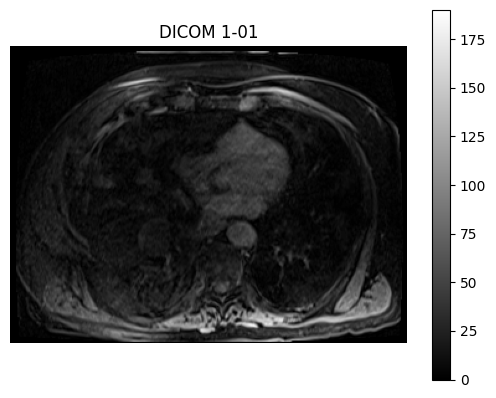

In [13]:
utils.view_dicom(sample_dcm_file)

In [14]:
utils.view_dicom(sample_dcm_dir)

Viewing DICOM series in directory: /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/TCIA_TCGA-LIHC_09-16-2015_subset_30/TCGA-LIHC/TCGA-BC-4073/02-21-2000-MRI ABD WWO CONT-85289/12.000000-t1vibeqfstrap2bhFIL-46615


interactive(children=(IntSlider(value=39, description='i', max=79), Output()), _dom_classes=('widget-interact'…

### Add acquisition time data for kidney

In [15]:
# if dataset == "tcga-kirc":
#     metadata_df = utils.update_phase_column_with_acquisition_time(metadata_df, image_dir)
#     metadata_df.head()

# Data filtering

In [16]:
metadata_df = utils.add_viable_info(image_subdir, metadata_df, min_files=5, max_thickness_mm=10, out=imaging_metadata_csv, overwrite=True)
metadata_df[["caseID", "Series UID", "is_viable", "viable_reason"]].head()

INFO:tcga_radiogenomics.utils:Overwriting existing is_viable and viable_reason columns with new viability check results
Processing cases: 100%|██████████| 7/7 [00:00<00:00, 59.62it/s]


,caseID,Series UID,is_viable,viable_reason
0,case_00088,1.3.6.1.4.1.14519.5.2.1.3344.4008.805113105659...,True,Series appears viable
1,case_00100,1.3.6.1.4.1.14519.5.2.1.3344.4008.167614523833...,True,Series appears viable
2,case_00318,1.3.6.1.4.1.14519.5.2.1.3344.4008.180602335180...,True,Series appears viable
3,case_00519,1.3.6.1.4.1.14519.5.2.1.3344.4008.199400007458...,True,Series appears viable
4,case_00746,1.3.6.1.4.1.14519.5.2.1.3344.4008.180093687915...,True,Series appears viable


In [17]:
metadata_df = metadata_df[metadata_df["is_viable"]]
metadata_df = metadata_df[metadata_df["Modality"] == "CT"]
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

=== TOTALS ===
Total series:   7
Total studies:  7
Total patients: 7

=== BY MODALITY ===
          num_series  num_studies  num_patients
Modality                                       
CT                 7            7             7

=== BY MODALITY + REGION ===
                         num_series  num_studies  num_patients
Modality ParsedRegion                                         
CT       Abdomen                  4            4             4
         Abdomen/Pelvis           2            2             2
         Chest                    1            1             1



,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,is_4d,max_zoom,Number of Images Standardized,is_viable,viable_reason
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,False,7.0,91,True,Series appears viable
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,False,5.0,91,True,Series appears viable
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,False,2.5,91,True,Series appears viable
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,False,2.5,91,True,Series appears viable
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,False,5.0,91,True,Series appears viable


# DICOM to NIfTI

In [18]:
image_filename = "imaging.nii.gz"
tumor_mask_filename = None
nifti_dir = os.path.join(data_dir, "nifti")

if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
    utils.convert_dcm_to_nii_and_organize(image_dir, metadata_df, nifti_dir, segimage2itkimage_conda=False)

In [19]:
# filter out 4D volumes and niis with big max zoom (sometimes some series will have an axial localizer but an otherwise coronal/sagittal series - we want to exclude these)
metadata_df = utils.check_and_delete_bad_niftis(metadata_df, nifti_dir, image_filename=image_filename, is_4d=True, max_zoom_maximum=20)
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

=== TOTALS ===
Total series:   7
Total studies:  7
Total patients: 7

=== BY MODALITY ===
          num_series  num_studies  num_patients
Modality                                       
CT                 7            7             7

=== BY MODALITY + REGION ===
                         num_series  num_studies  num_patients
Modality ParsedRegion                                         
CT       Abdomen                  4            4             4
         Abdomen/Pelvis           2            2             2
         Chest                    1            1             1



,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,Number of Images Standardized,is_viable,viable_reason,is_4d,max_zoom
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,91,True,Series appears viable,False,7.0
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,5.0
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,2.5
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,2.5
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,91,True,Series appears viable,False,5.0


In [20]:
if using_usc_data and dataset == "tcga-kirc":
    imaging_metadata_csv = os.path.join(data_dir, "metadata_usc.csv")
    nifti_dir_name_usc = "nifti_usc"
    nifti_dir = os.path.join(data_dir, nifti_dir_name_usc)
    image_filename = "0502_VENOUS.nii"
    tumor_mask_filename = "segmentation_tumor.nii.gz"

    if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
        tcga_kirc_images_dir = utils.download_usc_tcga_kirc_data(data_dir, imaging_metadata_csv=imaging_metadata_csv, num_cases=num_cases, dst_dir_name=nifti_dir_name_usc)

    metadata_df = pd.read_csv(imaging_metadata_csv)

In [21]:
!tree -L 2 {nifti_dir}

/mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti
├── case_00088
│   ├── 1.3.6.1.4.1.14519.5.2.1.3344.4008.805113105659291783647019874041_Eq_1.nii.gz
│   ├── 1.3.6.1.4.1.14519.5.2.1.3344.4008.805113105659291783647019874041.json
│   ├── image_standardized.nii.gz
│   ├── imaging.nii.gz
│   ├── imaging_oriented_clipped.nii.gz
│   ├── imaging_oriented_clipped_resampled.nii.gz
│   ├── imaging_oriented_clipped_resampled_normalized.nii.gz
│   ├── imaging_oriented.nii.gz
│   ├── segmentation_kidneys.nii.gz
│   ├── segmentation.nii.gz
│   ├── segmentation_organs.nii.gz
│   ├── segmentation_resampled.nii.gz
│   ├── segmentation_standardized.nii.gz
│   └── totalsegmentator
├── case_00100
│   ├── 1.3.6.1.4.1.14519.5.2.1.3344.4008.167614523833384850416961623267.json
│   ├── imaging.nii.gz
│   ├── imaging_oriented_clipped.nii.gz
│   ├── imaging_oriented_clipped_resampled.nii.gz
│   ├── imaging_oriented_clipped_resampled_normalized.nii.gz
│   ├── imaging_oriented.nii.gz
│   ├── segmentati

In [22]:
caseid_for_sample_uid = metadata_df["caseID"].iloc[0]  # metadata_df[metadata_df["Series UID"] == uid].iloc[0]["caseID"]
sample_nii_dir = os.path.join(nifti_dir, caseid_for_sample_uid)
sample_nii_file = os.path.join(sample_nii_dir, image_filename)

print(sample_nii_file)

/mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging.nii.gz


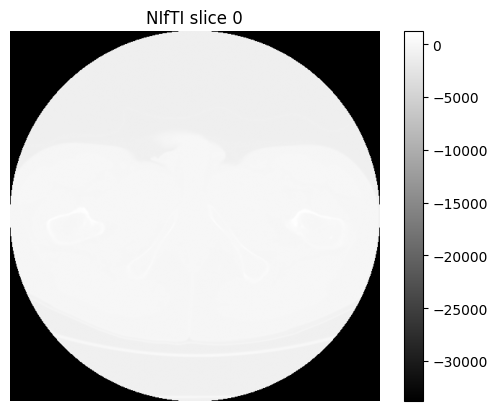

In [23]:
utils.view_nifti(sample_nii_file, z=0)

In [24]:
utils.view_nifti(sample_nii_file)

interactive(children=(IntSlider(value=67, description='z', max=134), Output()), _dom_classes=('widget-interact…

# Orientation

In [25]:
orient = True

oriented_image_files, final_image_files, final_mask_files = [], [], []
for caseID in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
    case_dir = os.path.join(nifti_dir, caseID)
    image_file = os.path.join(case_dir, image_filename)
    mask_file = os.path.join(case_dir, tumor_mask_filename) if tumor_mask_filename else ""
    if not os.path.exists(image_file):
        print(f"Image file not found for caseID {caseID} at {image_file}. Skipping.")
        continue

    if orient:
        image_file = utils.set_canonical_orientation(image_file, out=True)
        oriented_image_files.append(image_file)
        print(f"Set canonical orientation for image file for caseID {caseID} at {image_file}.")
        if os.path.exists(mask_file):
            mask_file = utils.set_canonical_orientation(mask_file, out=True)
    
    final_image_files.append(image_file)
    final_mask_files.append(mask_file)

image_filename_set = set([os.path.basename(f) for f in final_image_files])
assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
image_filename = list(image_filename_set)[0]
tumor_mask_filename = os.path.basename(final_mask_files[0]) if final_mask_files else ""

Processing images: 100%|██████████| 7/7 [00:00<00:00, 13592.65it/s]

Set canonical orientation for image file for caseID case_00088 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging_oriented.nii.gz.
Set canonical orientation for image file for caseID case_00100 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00100/imaging_oriented.nii.gz.
Set canonical orientation for image file for caseID case_00318 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00318/imaging_oriented.nii.gz.
Set canonical orientation for image file for caseID case_00519 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00519/imaging_oriented.nii.gz.
Set canonical orientation for image file for caseID case_00746 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00746/imaging_oriented.nii.gz.
Set canonical orientation for image file for caseID case_00798 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00798/imaging_oriented.nii.gz.
Set canonical or

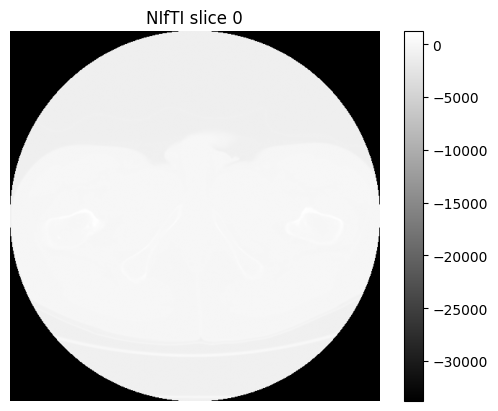

In [26]:
if oriented_image_files:
    utils.view_nifti(oriented_image_files[0], z=0)

# Organ and tumor segmentation

## Tumor segmentation

In [27]:
#!!! fill this in
# tumor_mask_filename = "segmentation_tumor.nii.gz"

## Organ segmentation with TotalSegmentator

In [28]:
metadata_df.head(40)

,caseID,Subject ID,Patient Name,Patient Birth Date,Patient Sex,Ethnic Group,Phantom,Species Code,Species Description,Study UID,...,File Size,Date Released,Third Party Analysis,ParsedRegion,tumor_side,Number of Images Standardized,is_viable,viable_reason,is_4d,max_zoom
0,case_00088,TCGA-DD-A3A4,TCGA-DD-A3A4,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.311274252956...,...,71194238,2013-10-07 23:04:49.0,NaN,Abdomen/Pelvis,NaN,91,True,Series appears viable,False,7.0
1,case_00100,TCGA-DD-A113,TCGA-DD-A113,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.125504002793...,...,23717160,2014-03-13 20:11:37.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,5.0
2,case_00318,TCGA-DD-A4NQ,TCGA-DD-A4NQ,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.144261437704...,...,93279498,2014-03-13 21:17:56.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,2.5
3,case_00519,TCGA-DD-A4NO,TCGA-DD-A4NO,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.226816019260...,...,61678340,2014-03-13 23:52:26.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,2.5
4,case_00746,TCGA-DD-A1EH,TCGA-DD-A1EH,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.266568840516...,...,39527576,2014-03-13 23:59:34.0,NaN,Chest,NaN,91,True,Series appears viable,False,5.0
5,case_00798,TCGA-DD-A1EJ,TCGA-DD-A1EJ,NaN,F,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.272963188777...,...,24308700,2014-03-14 01:57:47.0,NaN,Abdomen/Pelvis,NaN,91,True,Series appears viable,False,5.0
6,case_00887,TCGA-DD-A4NL,TCGA-DD-A4NL,NaN,M,NaN,NO,337915000,Homo sapiens,1.3.6.1.4.1.14519.5.2.1.3344.4008.283305018370...,...,64826670,2014-03-14 04:19:13.0,NaN,Abdomen,NaN,91,True,Series appears viable,False,2.5


In [29]:
combined_organ_mask_filename = "segmentation_organs.nii.gz"
mask_filename = "segmentation.nii.gz"

utils.run_totalsegmentator(nifti_dir, selected_segmentations=tcia_dataset_to_info[dataset]["totalsegmentator_organs"], metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, remove_small_blobs=True, fill_holes=True, morphological_closing=True, image_filename=image_filename, tumor_mask_filename=tumor_mask_filename, combined_organ_mask_filename=combined_organ_mask_filename, mask_filename_out=mask_filename, visualize=True)
metadata_df = pd.read_csv(imaging_metadata_csv)

INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID case_00088.
INFO:tcga_radiogenomics.utils:Visualizing caseID case_00088...
Visualizing slices for caseID case_00088: 100%|██████████| 135/135 [00:00<00:00, 458.00it/s]
INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID case_00100.
INFO:tcga_radiogenomics.utils:Visualizing caseID case_00100...
Visualizing slices for caseID case_00100: 100%|██████████| 45/45 [00:00<00:00, 532.55it/s]
INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID case_00318.
INFO:tcga_radiogenomics.utils:Visualizing caseID case_00318...
Visualizing slices for caseID case_00318: 100%|██████████| 177/177 [00:00<00:00, 467.03it/s]
INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID case_00519.
INFO:tcga_radiogenomics.utils:Visualizing caseID case_00519...
Visualizing slices for caseID case_00519: 100%|██████████| 117/117 [00:00<00:00, 469.19it/s]
INFO:tcga_radi

In [ ]:
sample_nii_mask_file = os.path.join(sample_nii_dir, mask_filename)
utils.view_nifti(sample_nii_mask_file)

interactive(children=(IntSlider(value=67, description='z', max=134), Output()), _dom_classes=('widget-interact…

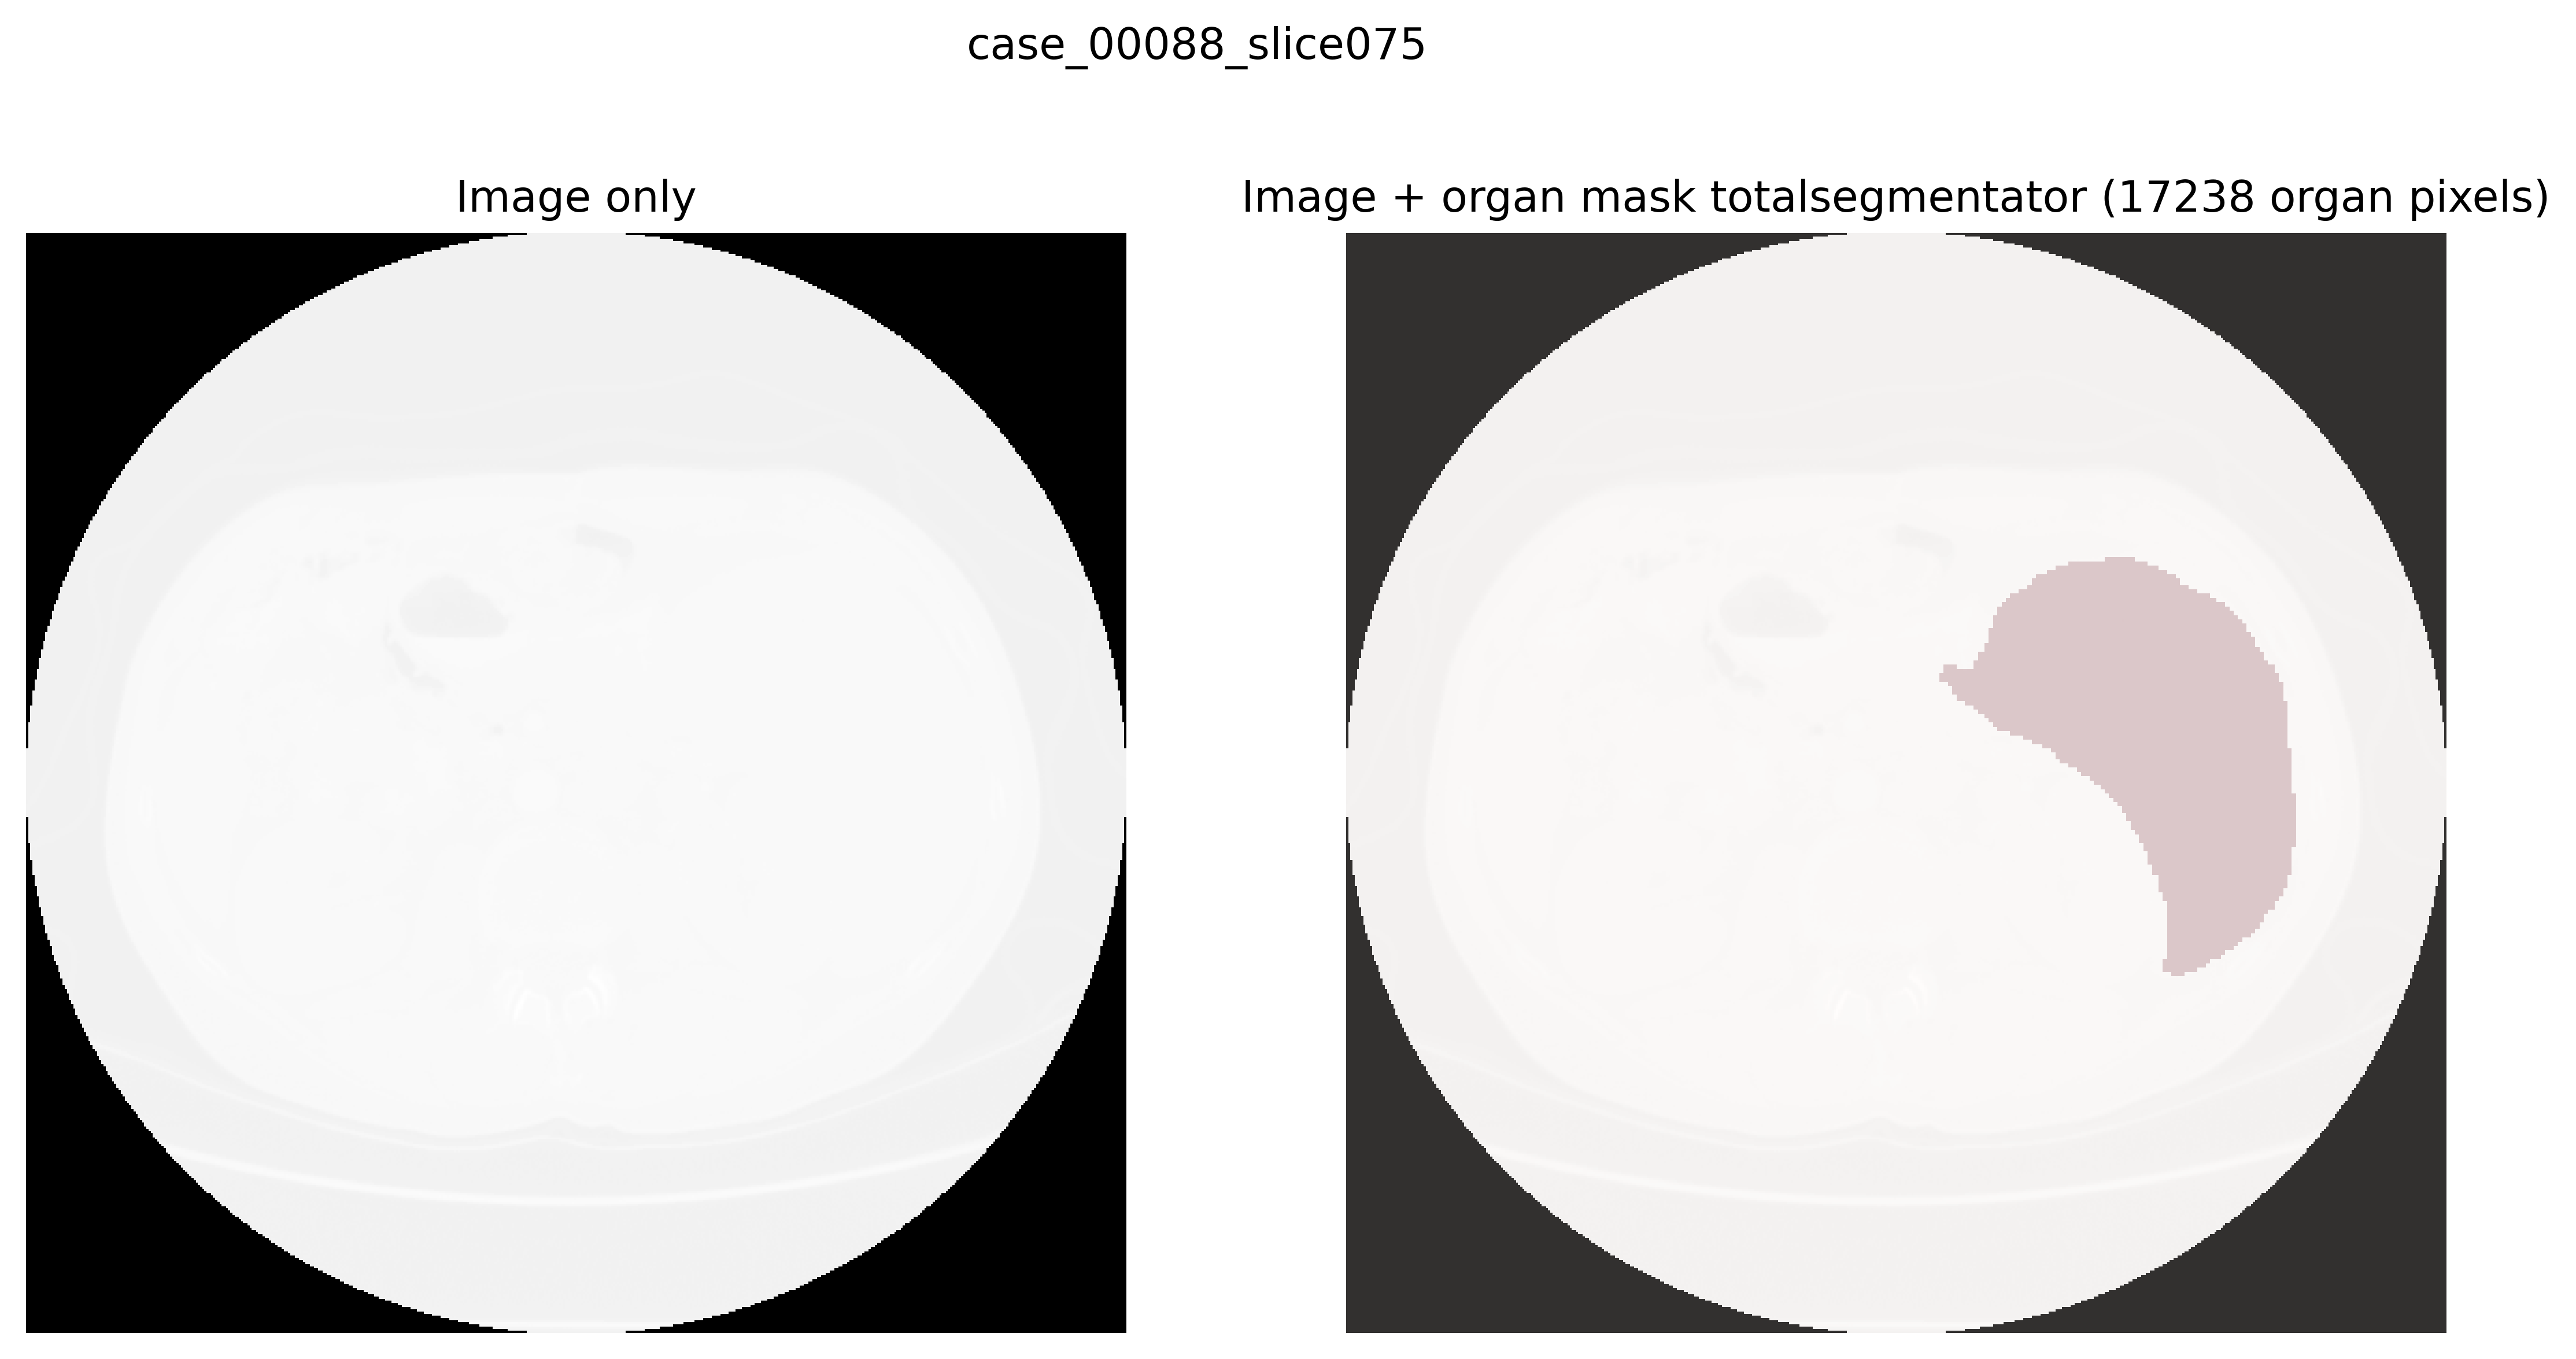

In [31]:
sample_totalsegmentator_visualization_dir = os.path.join(sample_nii_dir, "totalsegmentator", "visualization")
sample_totalsegmentator_visualization_file = None
for file in os.listdir(sample_totalsegmentator_visualization_dir):
    if file.endswith("_K.png"):
        sample_totalsegmentator_visualization_file = os.path.join(sample_totalsegmentator_visualization_dir, file)
        break
if sample_totalsegmentator_visualization_file:
    display(Image(filename=sample_totalsegmentator_visualization_file))
else:
    print(f"No visualization file with organ found in {sample_totalsegmentator_visualization_dir}")

# Clipping, resampling, and intensity normalization

In [32]:
clip_min, clip_max = -200, 300
resample = True if not do_radiomics else False  # handled inside params yaml file for radiomics
normalize = True if not do_radiomics else False  # handled inside params yaml file for radiomics
normalization_method = "volume"

clipped_image_files, resampled_image_files, normalized_image_files, final_image_files = [], [], [], []
for caseID in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
    case_dir = os.path.join(nifti_dir, caseID)
    image_file = os.path.join(case_dir, image_filename)
    mask_file = os.path.join(case_dir, mask_filename) if mask_filename else ""
    if not os.path.exists(image_file):
        print(f"Image file not found for caseID {caseID} at {image_file}. Skipping.")
        continue
    
    if clip_min is not None or clip_max is not None:  # eg (-200, 300) for soft tissue window - done in training loop
        print(f"Clipping intensity range for image file for caseID {caseID} at {image_file} with clip_min={clip_min}, clip_max={clip_max}.")
        image_file = utils.clip_intensity_range(image_file, clip_min=clip_min, clip_max=clip_max, out=True)
        clipped_image_files.append(image_file)

    if resample:
        image_file = utils.resample_image(image_file, target_spacing=(0.8, 0.8, 3.0), is_label=False, out=True)
        resampled_image_files.append(image_file)
        print(f"Resampled image file for caseID {caseID} at {image_file}.")
        if os.path.exists(mask_file):
            mask_file = utils.resample_image(mask_file, target_spacing=(0.8, 0.8, 3.0), is_label=True, out=True)
    
    if normalize:  # done in training loop
        print(f"Normalizing intensity for image file for caseID {caseID} at {image_file}.")
        image_file = utils.normalize_intensity(image_file, out=True)
        normalized_image_files.append(image_file)

    final_image_files.append(image_file)

image_filename_set = set([os.path.basename(f) for f in final_image_files])
assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
image_filename = list(image_filename_set)[0]

Processing images:   0%|          | 0/7 [00:00<?, ?it/s]

Clipping intensity range for image file for caseID case_00088 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging_oriented.nii.gz with clip_min=-200, clip_max=300.
Resampled image file for caseID case_00088 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging_oriented_clipped_resampled.nii.gz.
Normalizing intensity for image file for caseID case_00088 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging_oriented_clipped_resampled.nii.gz.


Processing images:  14%|█▍        | 1/7 [00:01<00:09,  1.65s/it]

Clipping intensity range for image file for caseID case_00100 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00100/imaging_oriented.nii.gz with clip_min=-200, clip_max=300.
Resampled image file for caseID case_00100 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00100/imaging_oriented_clipped_resampled.nii.gz.
Normalizing intensity for image file for caseID case_00100 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00100/imaging_oriented_clipped_resampled.nii.gz.


Processing images:  29%|██▊       | 2/7 [00:02<00:04,  1.08it/s]

...

Processing images:  71%|███████▏  | 5/7 [00:04<00:01,  1.39it/s]

Clipping intensity range for image file for caseID case_00798 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00798/imaging_oriented.nii.gz with clip_min=-200, clip_max=300.
Resampled image file for caseID case_00798 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00798/imaging_oriented_clipped_resampled.nii.gz.
Normalizing intensity for image file for caseID case_00798 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00798/imaging_oriented_clipped_resampled.nii.gz.


Processing images:  86%|████████▌ | 6/7 [00:04<00:00,  1.64it/s]

Clipping intensity range for image file for caseID case_00887 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00887/imaging_oriented.nii.gz with clip_min=-200, clip_max=300.
Resampled image file for caseID case_00887 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00887/imaging_oriented_clipped_resampled.nii.gz.
Normalizing intensity for image file for caseID case_00887 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00887/imaging_oriented_clipped_resampled.nii.gz.


Processing images: 100%|██████████| 7/7 [00:05<00:00,  1.30it/s]


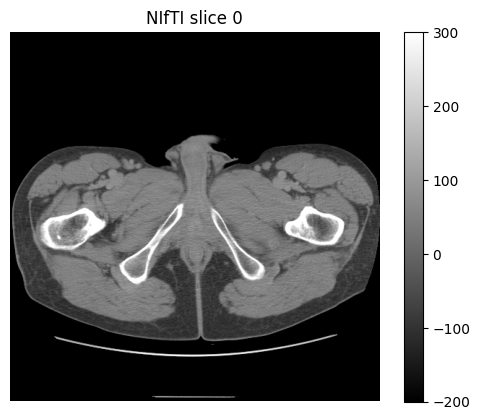

In [33]:
if clipped_image_files:
    utils.view_nifti(clipped_image_files[0], z=0)

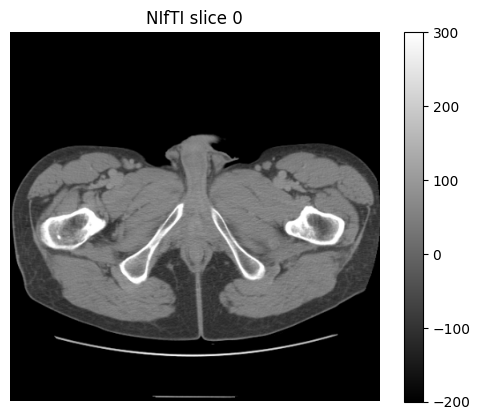

In [34]:
if resampled_image_files:
    utils.view_nifti(resampled_image_files[0], z=0)

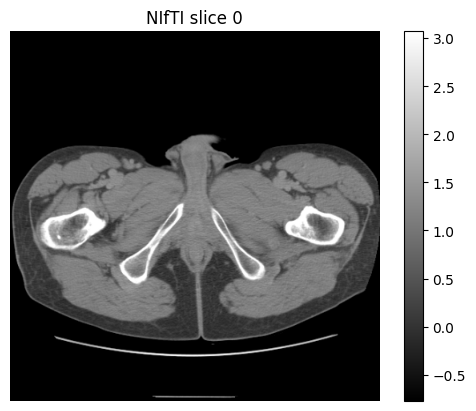

In [35]:
if normalized_image_files:
    utils.view_nifti(normalized_image_files[0], z=0)

In [36]:
if not do_radiomics:
    final_image_files_stats = utils.check_dataset_intensity_consistency(final_image_files)
    print(final_image_files_stats[0])

INFO:tcga_radiogenomics.utils:Intensity QC PASSED.


{'path': '/mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/nifti/case_00088/imaging_oriented_clipped_resampled_normalized.nii.gz', 'min': np.float64(-0.7725417613983154), 'max': np.float64(3.068251371383667), 'mean': np.float64(-1.006638556661619e-06), 'std': np.float64(1.0000051505372347)}


# Region selection

## 3D

In [37]:
if image_dimensionality == "3D":
    if do_radiomics:
        print("Skipping, as radiomics features should be extracted from full images/volume.")
    else:
        image_filename, mask_filename = utils.standardize_volume(nifti_dir, metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, image_filename=image_filename, mask_filename=mask_filename)
        metadata_df = pd.read_csv(imaging_metadata_csv)

INFO:tcga_radiogenomics.utils:Using fixed z range (95th percentile): 90
INFO:tcga_radiogenomics.utils:Saved histogram to /mnt/gpussd2/jrich/data/radiogenomics/tcga-lihc/imaging/visualization/organ_z_extent_histogram.png


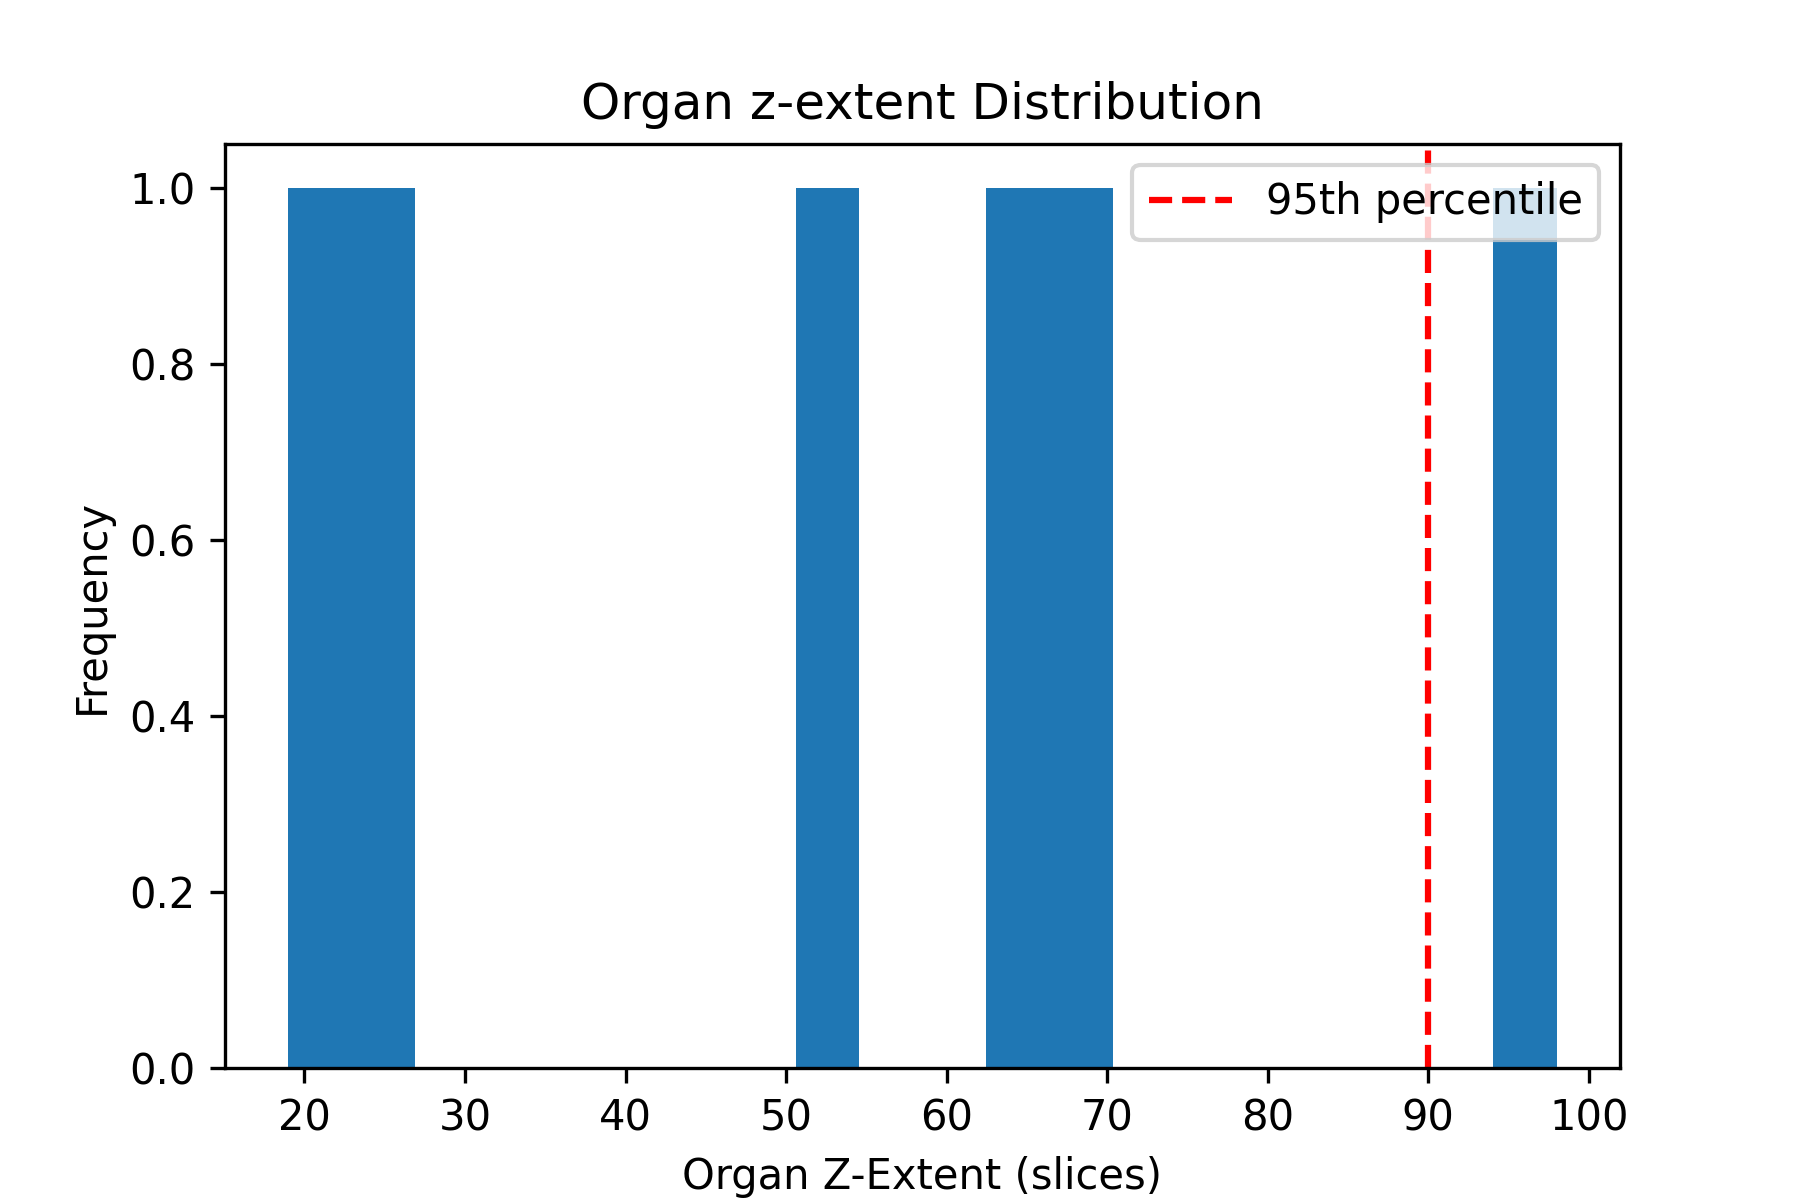

In [38]:
# internal to utils.standardize_volume
visualization_dir = os.path.join(os.path.dirname(nifti_dir), "visualization")
hist_path = os.path.join(visualization_dir, "organ_z_extent_histogram.png")
display(Image(hist_path))

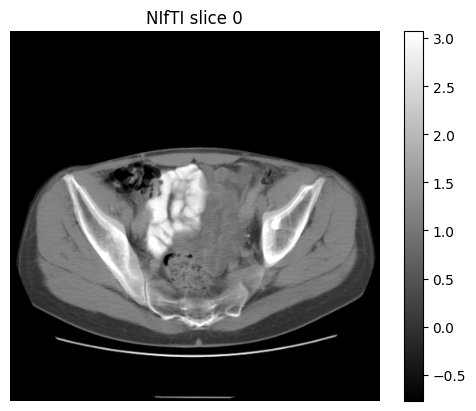

In [39]:
if image_dimensionality == "3D":
    utils.view_nifti(os.path.join(sample_nii_dir, image_filename), z=0)

### At this point, you can pass these 3D images and masks to your training loop, or you can perform radiomics feature extraction with pyradiomics.

## 2D

In [40]:
if image_dimensionality == "2D":
    mask_value = 2 if tumor_mask_filename else 1  # use tumor if available, otherwise use organs
    image_filename, mask_filename = utils.choose_slice_with_most_tumor(nifti_dir, metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, image_filename=image_filename, mask_filename=mask_filename, tumor_mask_value=mask_value)
    metadata_df = pd.read_csv(imaging_metadata_csv)

In [41]:
if image_dimensionality == "2D":
    utils.view_nifti(os.path.join(sample_nii_dir, image_filename), z=0)

### At this point, you can pass these 2D images and masks to your training loop, or you can perform radiomics feature extraction with pyradiomics.

# Radiomic feature extraction

In [42]:
print(f"Final image filename: {image_filename}, Final mask filename: {mask_filename}")

Final image filename: image_standardized.nii.gz, Final mask filename: segmentation_standardized.nii.gz


In [43]:
if do_radiomics:
    pyradiomics_param_file = os.path.join(data_dir, f"pyradiomics_param.yaml")
    with open(pyradiomics_param_file, "w") as f:
        yaml.dump(pyradiomics_param, f, sort_keys=False, default_flow_style=False)

    pyradiomics_input_csv_path = os.path.join(data_dir, f"metadata_{image_dimensionality}_preradiomics.csv")
    utils.prepare_csv_for_pyradiomics(nifti_dir, output_csv_path=pyradiomics_input_csv_path, metadata_df=metadata_df, imaging_file_name=image_filename, mask_file_name=mask_filename)

    output_csv_path = os.path.join(data_dir, f"metadata_{image_dimensionality}_radiomics.csv")
    utils.perform_radiomics_pipeline(pyradiomics_input_csv_path, output_csv_path=output_csv_path, label=1, param=pyradiomics_param_file)

    radiomics_df = pd.read_csv(output_csv_path)
    radiomics_df.head()

### At this point, you can pass these radiomic features to your training loop, or you can perform feature selection and dimensionality reduction before training.

# Package versions

In [44]:
!pip list

Package                       Version      Editable project location
----------------------------- ------------ ---------------------------------------------
acvl_utils                    0.2.5
annotated-doc                 0.0.4
anyio                         4.12.1
asttokens                     3.0.1
batchgenerators               0.25.1
batchgeneratorsv2             0.3.0
blosc2                        4.1.0
certifi                       2026.2.25
charset-normalizer            3.4.4
click                         8.3.1
comm                          0.2.3
connected-components-3d       3.26.1
contourpy                     1.3.2
cuda-bindings                 12.9.4
cuda-pathfinder               1.4.0
cycler                        0.12.1
dcm2niix                      1.0.20250506
debugpy                       1.8.20
decorator                     5.2.1
dicom2nifti                   2.6.2
docopt                        0.6.2
dynamic_network_architectures 0.4.3
einops                        0.8